In [ ]:

# ============================================================
# Task 1: SALES FORECASTING & DEMAND INTELLIGENCE SYSTEM
# DATA LOADING, PREPROCESSING & EXPLORATION
# Prepared By: Yamini Nebhnani
# ============================================================

# ==========================
# Import Required Libraries
# ==========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from google.colab import files

warnings.filterwarnings("ignore")

print("="*60)
print("END-TO-END SALES FORECASTING PROJECT")
print("="*60)

# ==========================
# Upload Dataset
# ==========================
print("\nUpload train.csv")
uploaded = files.upload()

# ==========================
# Read Dataset
# ==========================
filename = list(uploaded.keys())[0]
dataset = pd.read_csv(filename)

print("\nDataset Loaded Successfully")
print("File Name :", filename)

# ==========================
# Display Dataset
# ==========================
print("\nFirst 5 Rows")
print(dataset.head())

print("\nLast 5 Rows")
print(dataset.tail())

# ==========================
# Dataset Shape
# ==========================
print("\nDataset Shape")
print(dataset.shape)

print("\nRows :", dataset.shape[0])
print("Columns :", dataset.shape[1])

# ==========================
# Column Names
# ==========================
print("\nColumn Names")
for col in dataset.columns:
    print(col)

# ==========================
# Dataset Information
# ==========================
print("\nDataset Information")
dataset.info()

# ==========================
# Statistical Summary
# ==========================
print("\nStatistical Summary")
print(dataset.describe(include='all'))

# ==========================
# Missing Values
# ==========================
print("\nMissing Values")
missing = dataset.isnull().sum()
print(missing)

print("\nTotal Missing Values :", missing.sum())

# ==========================
# Duplicate Records
# ==========================
duplicates = dataset.duplicated().sum()

print("\nDuplicate Rows :", duplicates)

# ==========================
# Convert Date Columns
# ==========================
dataset["Order Date"] = pd.to_datetime(
    dataset["Order Date"],
    dayfirst=True,
    errors="coerce"
)

dataset["Ship Date"] = pd.to_datetime(
    dataset["Ship Date"],
    dayfirst=True,
    errors="coerce"
)
print("\nDate Conversion Completed")

# ==========================
# Feature Engineering
# ==========================
dataset["Year"] = dataset["Order Date"].dt.year
dataset["Month"] = dataset["Order Date"].dt.month
dataset["Month Name"] = dataset["Order Date"].dt.month_name()
dataset["Week"] = dataset["Order Date"].dt.isocalendar().week
dataset["Quarter"] = dataset["Order Date"].dt.quarter
dataset["Day"] = dataset["Order Date"].dt.day_name()

# ==========================
# Create Season Column
# ==========================
def season(month):

    if month in [12,1,2]:
        return "Winter"

    elif month in [3,4,5]:
        return "Summer"

    elif month in [6,7,8]:
        return "Monsoon"

    else:
        return "Autumn"

dataset["Season"] = dataset["Month"].apply(season)

# ==========================
# Shipping Days
# ==========================
dataset["Shipping Days"] = (
    dataset["Ship Date"] -
    dataset["Order Date"]
).dt.days

print("\nShipping Days Created Successfully")

# ==========================
# Check New Dataset
# ==========================
print("\nUpdated Dataset")
print(dataset.head())

# ==========================
# Unique Values
# ==========================
print("\nUnique Categories")
print(dataset["Category"].unique())

print("\nUnique Regions")
print(dataset["Region"].unique())

print("\nUnique Segments")
print(dataset["Segment"].unique())

# ==========================
# Dataset Memory Usage
# ==========================
print("\nMemory Usage")
print(dataset.memory_usage(deep=True))

# ==========================
# Final Check
# ==========================
print("\nFinal Dataset Shape :", dataset.shape)

print("\n Completed Successfully")
print("="*60)

END-TO-END SALES FORECASTING PROJECT

Upload train.csv


Saving train.csv to train (3).csv

Dataset Loaded Successfully
File Name : train (3).csv

First 5 Rows
   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
1       2  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
2       3  CA-2017-138688  12/06/2017  16/06/2017    Second Class    DV-13045   
3       4  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   
4       5  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   

     Customer Name    Segment        Country             City       State  \
0      Claire Gute   Consumer  United States        Henderson    Kentucky   
1      Claire Gute   Consumer  United States        Henderson    Kentucky   
2  Darrin Van Huff  Corporate  United States      Los Angeles  California   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   
4   Sean O'Donnell   Cons

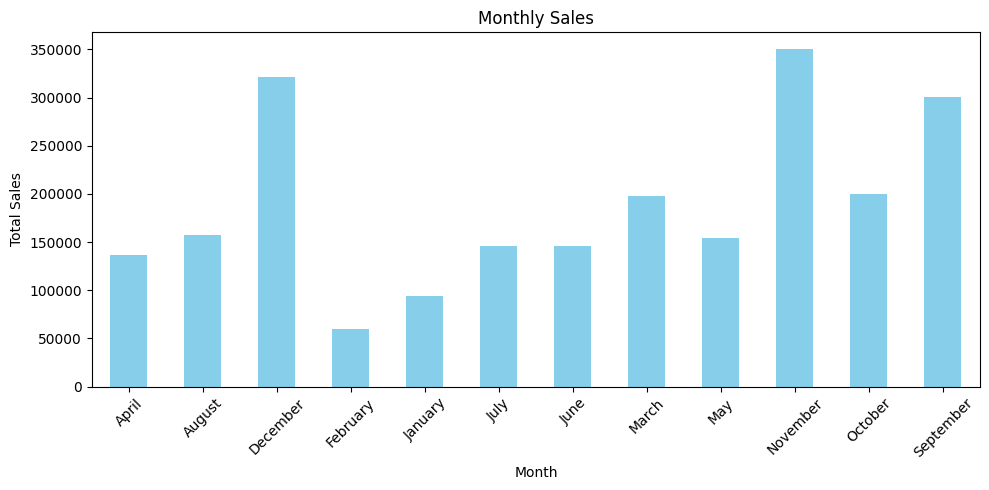

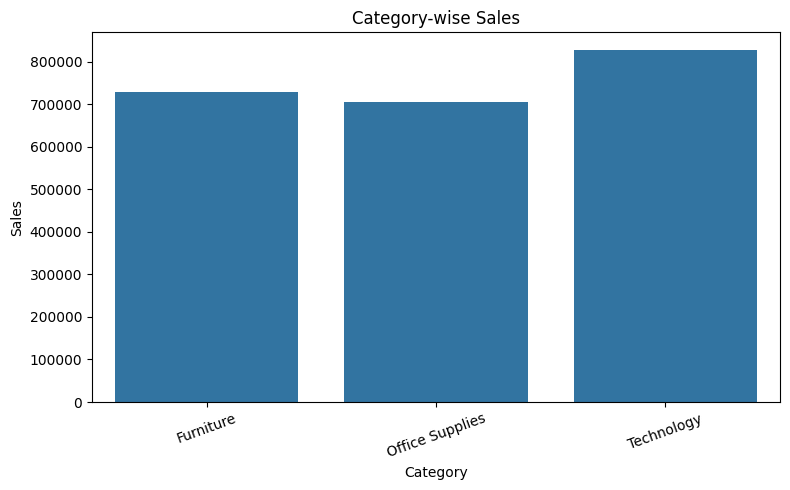

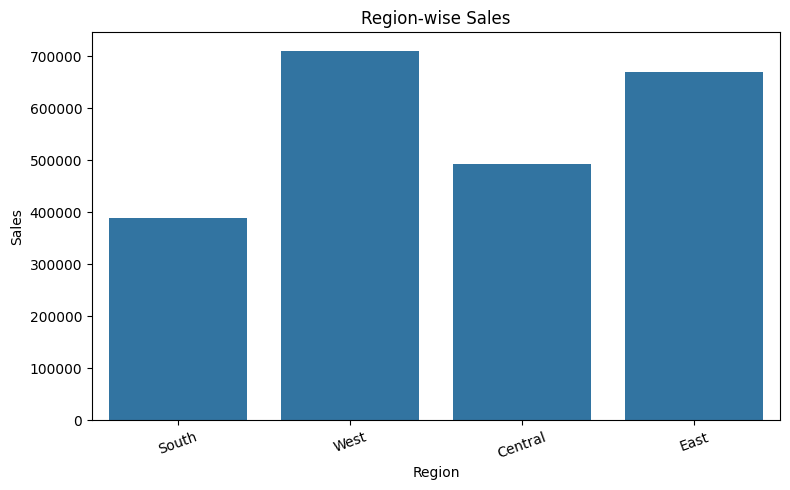

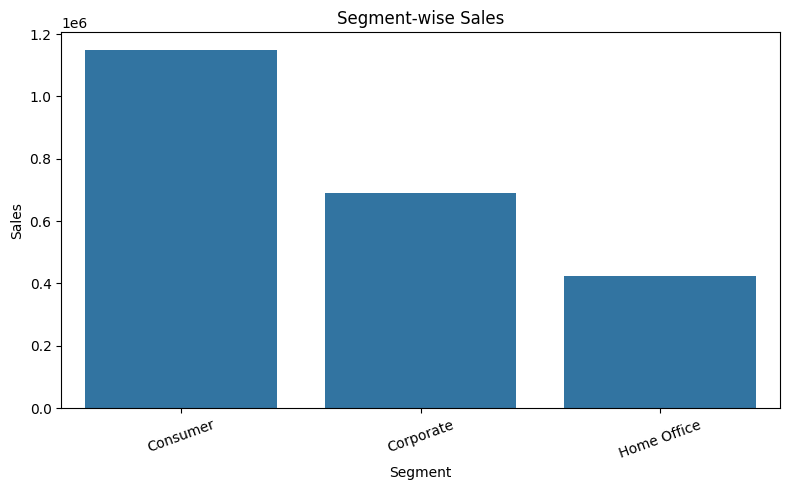

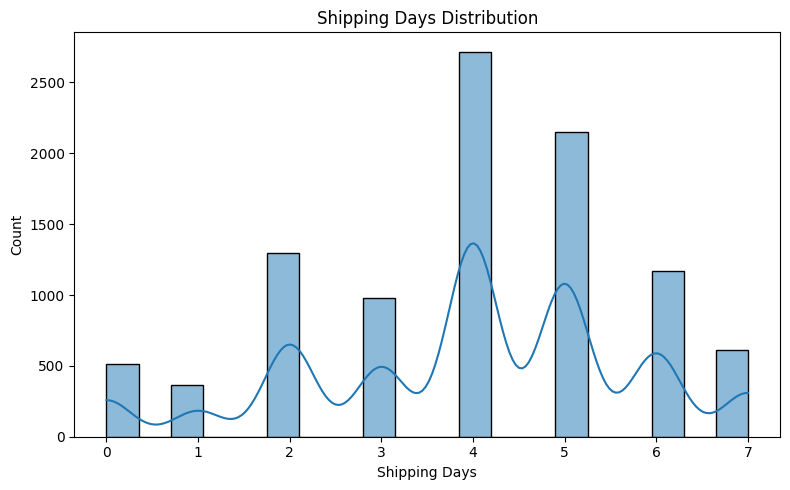

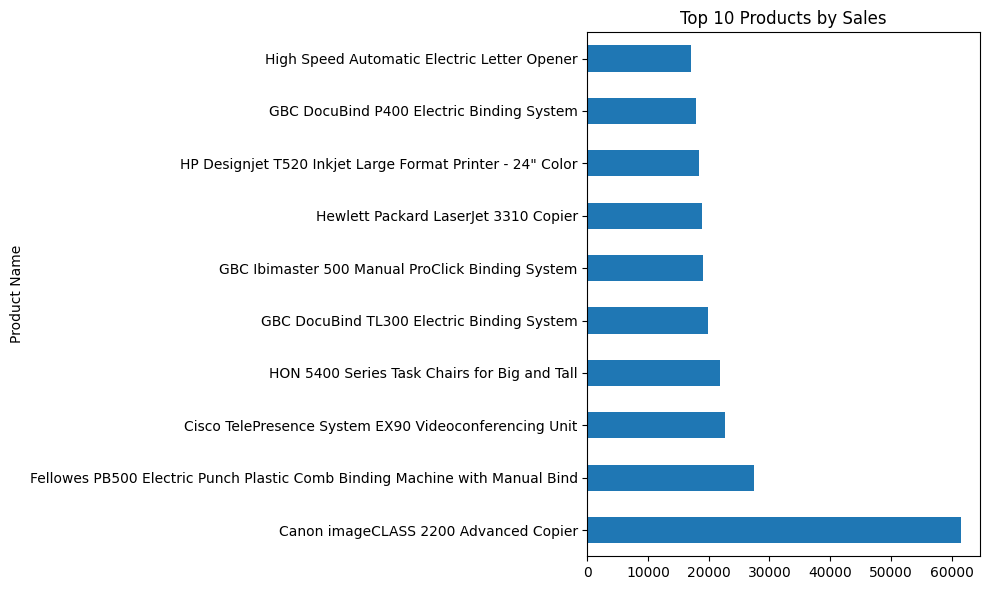

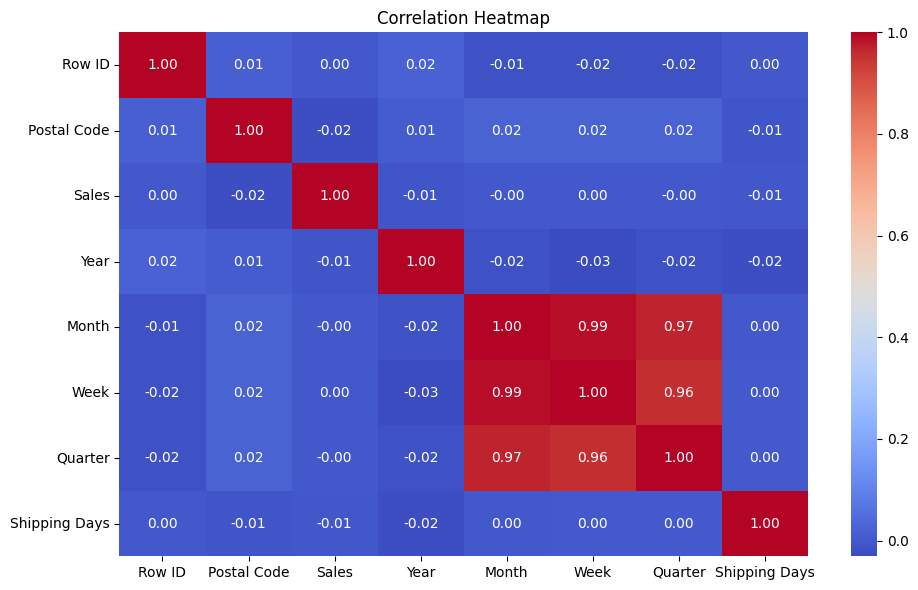


========== BUSINESS INSIGHTS ==========
1. Monthly sales trend has been analyzed.
2. Category-wise performance identified.
3. Region-wise sales compared.
4. Segment-wise sales analyzed.
5. Shipping duration explored.
6. Top-selling products identified.
7. Correlation among numeric variables examined.

Charts have been saved in the 'charts' folder.
Completed Successfully!


In [ ]:
# ============================================================
# BUSINESS ANALYSIS & VISUALIZATION
# ============================================================

import os
os.makedirs("charts", exist_ok=True)

# ============================================================
# Monthly Sales Analysis
# ============================================================
monthly_sales = dataset.groupby("Month Name")["Sales"].sum()

plt.figure(figsize=(10,5))
monthly_sales.plot(kind="bar", color="skyblue")
plt.title("Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("charts/monthly_sales.png")
plt.show()

# ============================================================
# Category-wise Sales
# ============================================================
plt.figure(figsize=(8,5))
sns.barplot(
    data=dataset,
    x="Category",
    y="Sales",
    estimator=sum,
    errorbar=None
)
plt.title("Category-wise Sales")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("charts/category_sales.png")
plt.show()

# ============================================================
# Region-wise Sales
# ============================================================
plt.figure(figsize=(8,5))
sns.barplot(
    data=dataset,
    x="Region",
    y="Sales",
    estimator=sum,
    errorbar=None
)
plt.title("Region-wise Sales")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("charts/region_sales.png")
plt.show()

# ============================================================
# Segment-wise Sales
# ============================================================
plt.figure(figsize=(8,5))
sns.barplot(
    data=dataset,
    x="Segment",
    y="Sales",
    estimator=sum,
    errorbar=None
)
plt.title("Segment-wise Sales")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("charts/segment_sales.png")
plt.show()

# ============================================================
# Shipping Days Distribution
# ============================================================
plt.figure(figsize=(8,5))
sns.histplot(dataset["Shipping Days"], bins=20, kde=True)
plt.title("Shipping Days Distribution")
plt.tight_layout()
plt.savefig("charts/shipping_days.png")
plt.show()

# ============================================================
# Top 10 Products by Sales
# ============================================================
top_products = (
    dataset.groupby("Product Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))
top_products.plot(kind="barh")
plt.title("Top 10 Products by Sales")
plt.tight_layout()
plt.savefig("charts/top_products.png")
plt.show()

# ============================================================
# Correlation Heatmap
# ============================================================
plt.figure(figsize=(10,6))
numeric_df = dataset.select_dtypes(include=["number"])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("charts/heatmap.png")
plt.show()

# ============================================================
# Business Insights
# ============================================================
print("\n========== BUSINESS INSIGHTS ==========")
print("1. Monthly sales trend has been analyzed.")
print("2. Category-wise performance identified.")
print("3. Region-wise sales compared.")
print("4. Segment-wise sales analyzed.")
print("5. Shipping duration explored.")
print("6. Top-selling products identified.")
print("7. Correlation among numeric variables examined.")

print("\nCharts have been saved in the 'charts' folder.")

print("Completed Successfully!")

,Sales
Order Date,
2015-01-03,16.448
2015-01-04,288.060
2015-01-05,19.536
2015-01-06,4407.100
2015-01-07,87.158


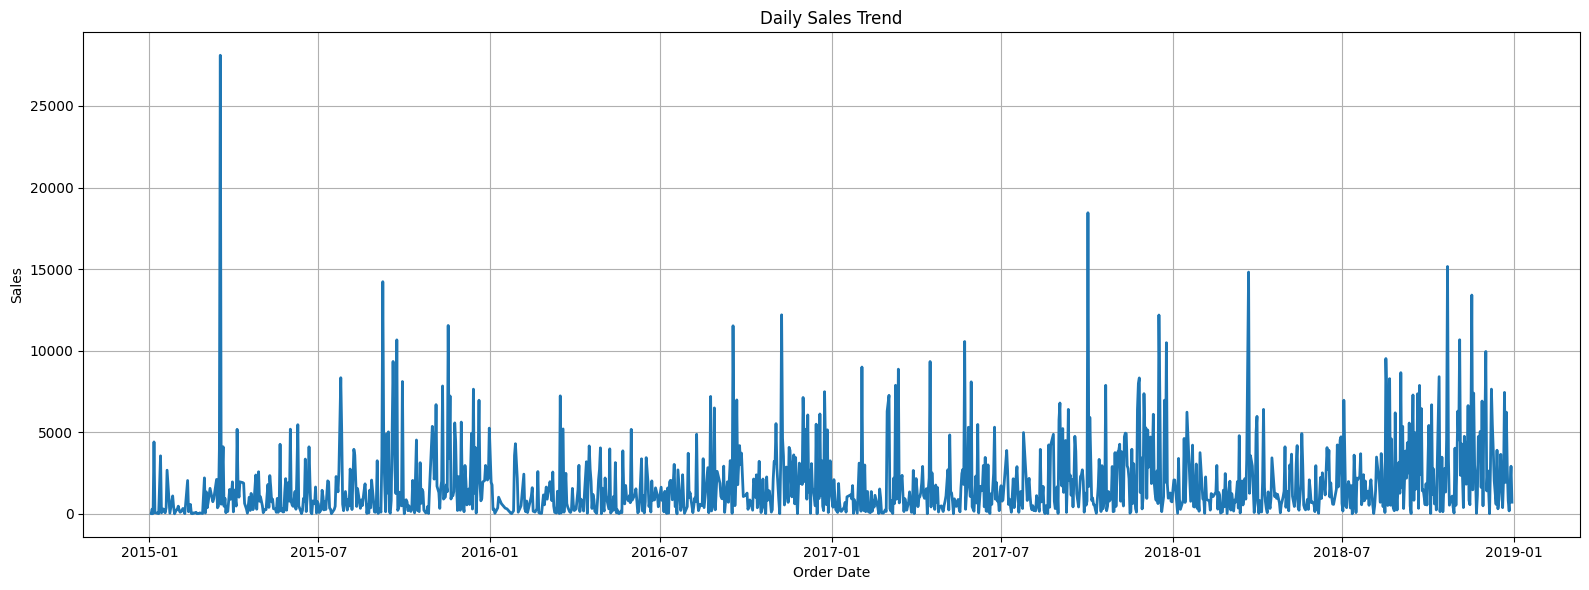

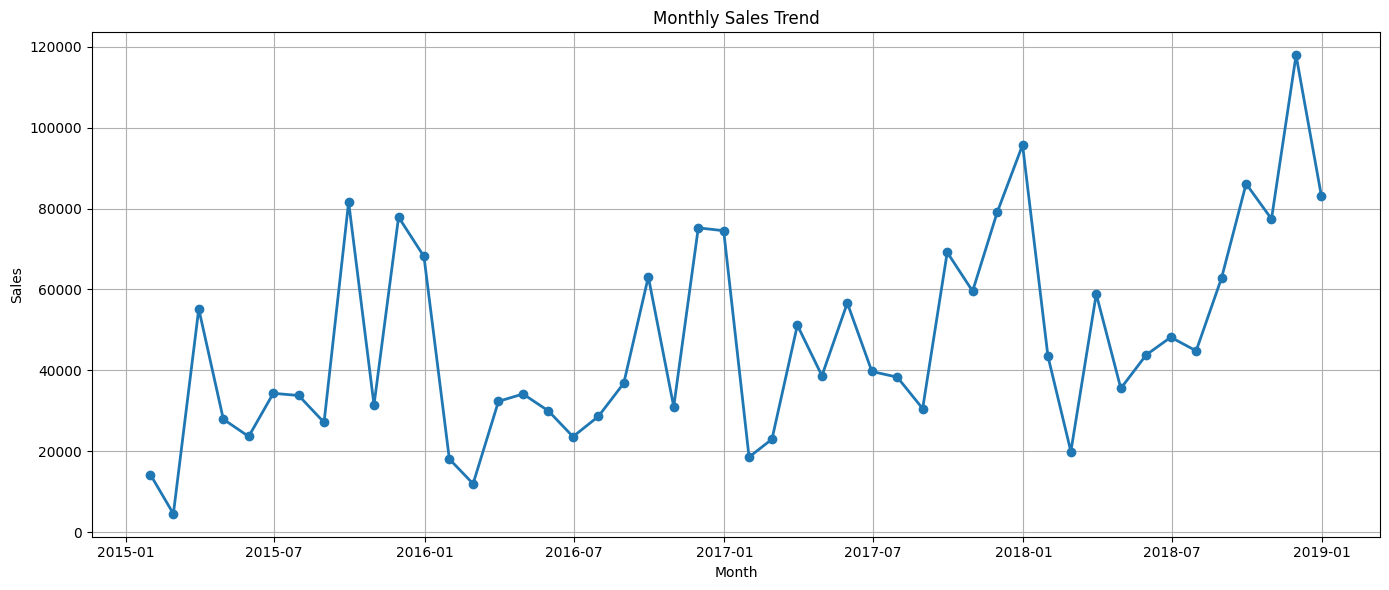

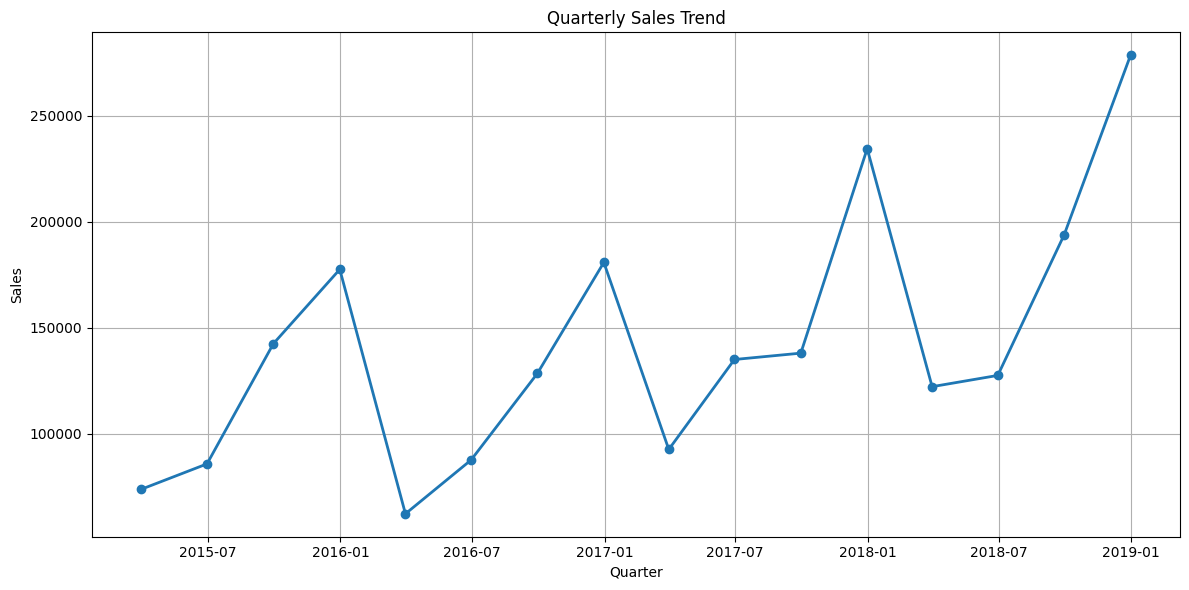

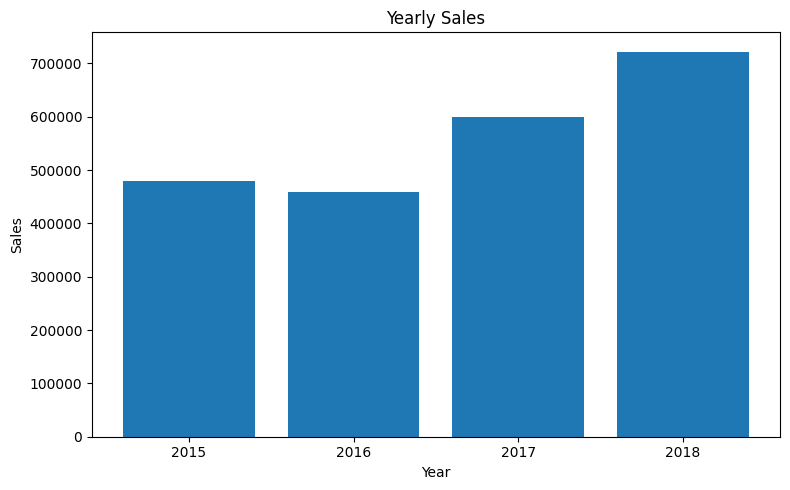

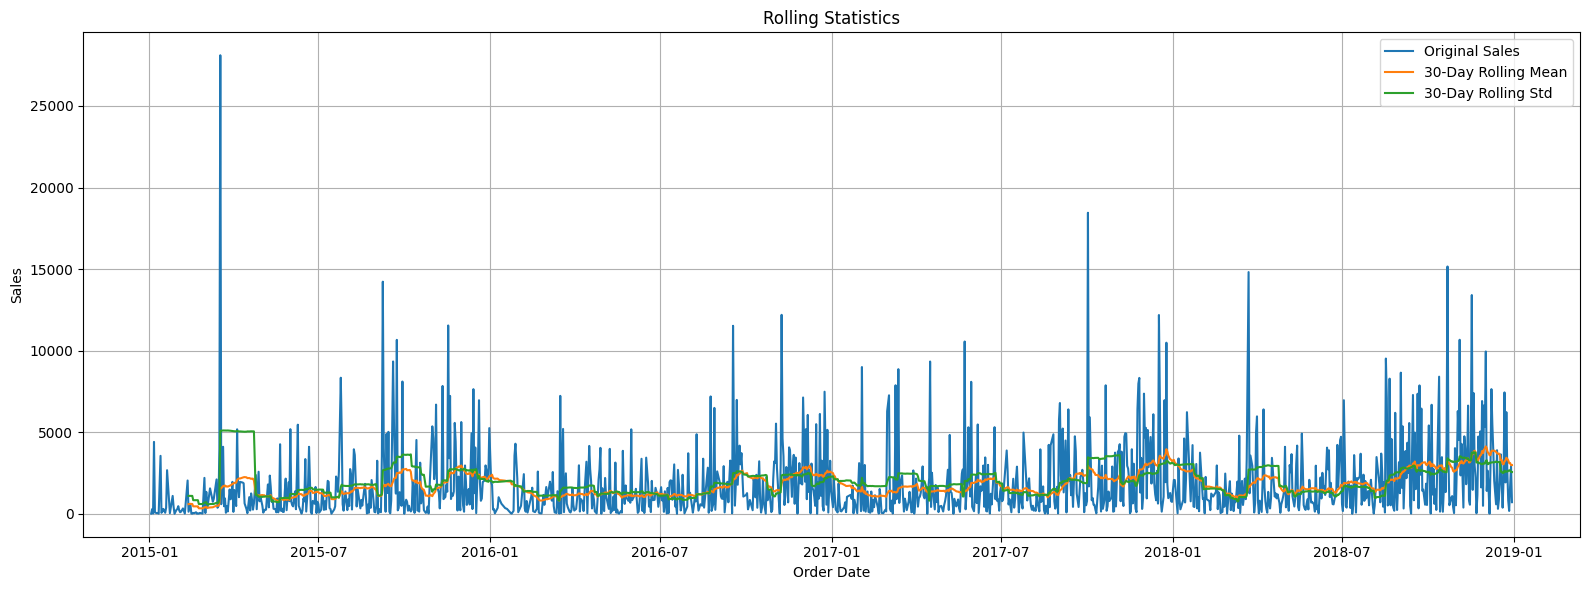

Training Records : 984
Testing Records  : 246


,Sales
Order Date,
2015-01-03,16.448
2015-01-04,288.060
2015-01-05,19.536
2015-01-06,4407.100
2015-01-07,87.158


,Sales
Order Date,
2018-04-07,1971.2905
2018-04-08,6401.9300
2018-04-09,1626.7100
2018-04-10,755.5290
2018-04-11,319.8060


In [ ]:

# Task 2: Time Series Preparation & Visualization

import os
import matplotlib.pyplot as plt

os.makedirs("charts", exist_ok=True)

# Daily Sales Time Series

daily_sales = (
    dataset.groupby("Order Date", as_index=False)["Sales"]
    .sum()
    .sort_values("Order Date")
)

ts = daily_sales.set_index("Order Date")

display(ts.head())

# Daily Sales Trend

plt.figure(figsize=(16,6))
plt.plot(ts.index, ts["Sales"], linewidth=2)
plt.title("Daily Sales Trend")
plt.xlabel("Order Date")
plt.ylabel("Sales")
plt.grid(True)
plt.tight_layout()
plt.savefig("charts/daily_sales_trend.png")
plt.show()

# Monthly Sales Trend

monthly_sales = ts.resample("ME").sum()

plt.figure(figsize=(14,6))
plt.plot(monthly_sales.index, monthly_sales["Sales"], marker="o", linewidth=2)
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.grid(True)
plt.tight_layout()
plt.savefig("charts/monthly_sales_trend.png")
plt.show()

# Quarterly Sales Trend

quarterly_sales = ts.resample("QE").sum()

plt.figure(figsize=(12,6))
plt.plot(quarterly_sales.index, quarterly_sales["Sales"], marker="o", linewidth=2)
plt.title("Quarterly Sales Trend")
plt.xlabel("Quarter")
plt.ylabel("Sales")
plt.grid(True)
plt.tight_layout()
plt.savefig("charts/quarterly_sales_trend.png")
plt.show()

# Yearly Sales Trend

yearly_sales = ts.resample("YE").sum()

plt.figure(figsize=(8,5))
plt.bar(yearly_sales.index.year.astype(str), yearly_sales["Sales"])
plt.title("Yearly Sales")
plt.xlabel("Year")
plt.ylabel("Sales")
plt.tight_layout()
plt.savefig("charts/yearly_sales.png")
plt.show()

# Rolling Statistics

rolling_mean = ts["Sales"].rolling(window=30).mean()
rolling_std = ts["Sales"].rolling(window=30).std()

plt.figure(figsize=(16,6))
plt.plot(ts.index, ts["Sales"], label="Original Sales")
plt.plot(ts.index, rolling_mean, label="30-Day Rolling Mean")
plt.plot(ts.index, rolling_std, label="30-Day Rolling Std")
plt.title("Rolling Statistics")
plt.xlabel("Order Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("charts/rolling_statistics.png")
plt.show()

# Train Test Split

split_index = int(len(ts) * 0.80)

train = ts.iloc[:split_index]
test = ts.iloc[split_index:]

print("Training Records :", len(train))
print("Testing Records  :", len(test))

display(train.head())
display(test.head())

ADF Statistic : -5.761112092918502
p-value : 5.669526815779355e-07
The time series is stationary.


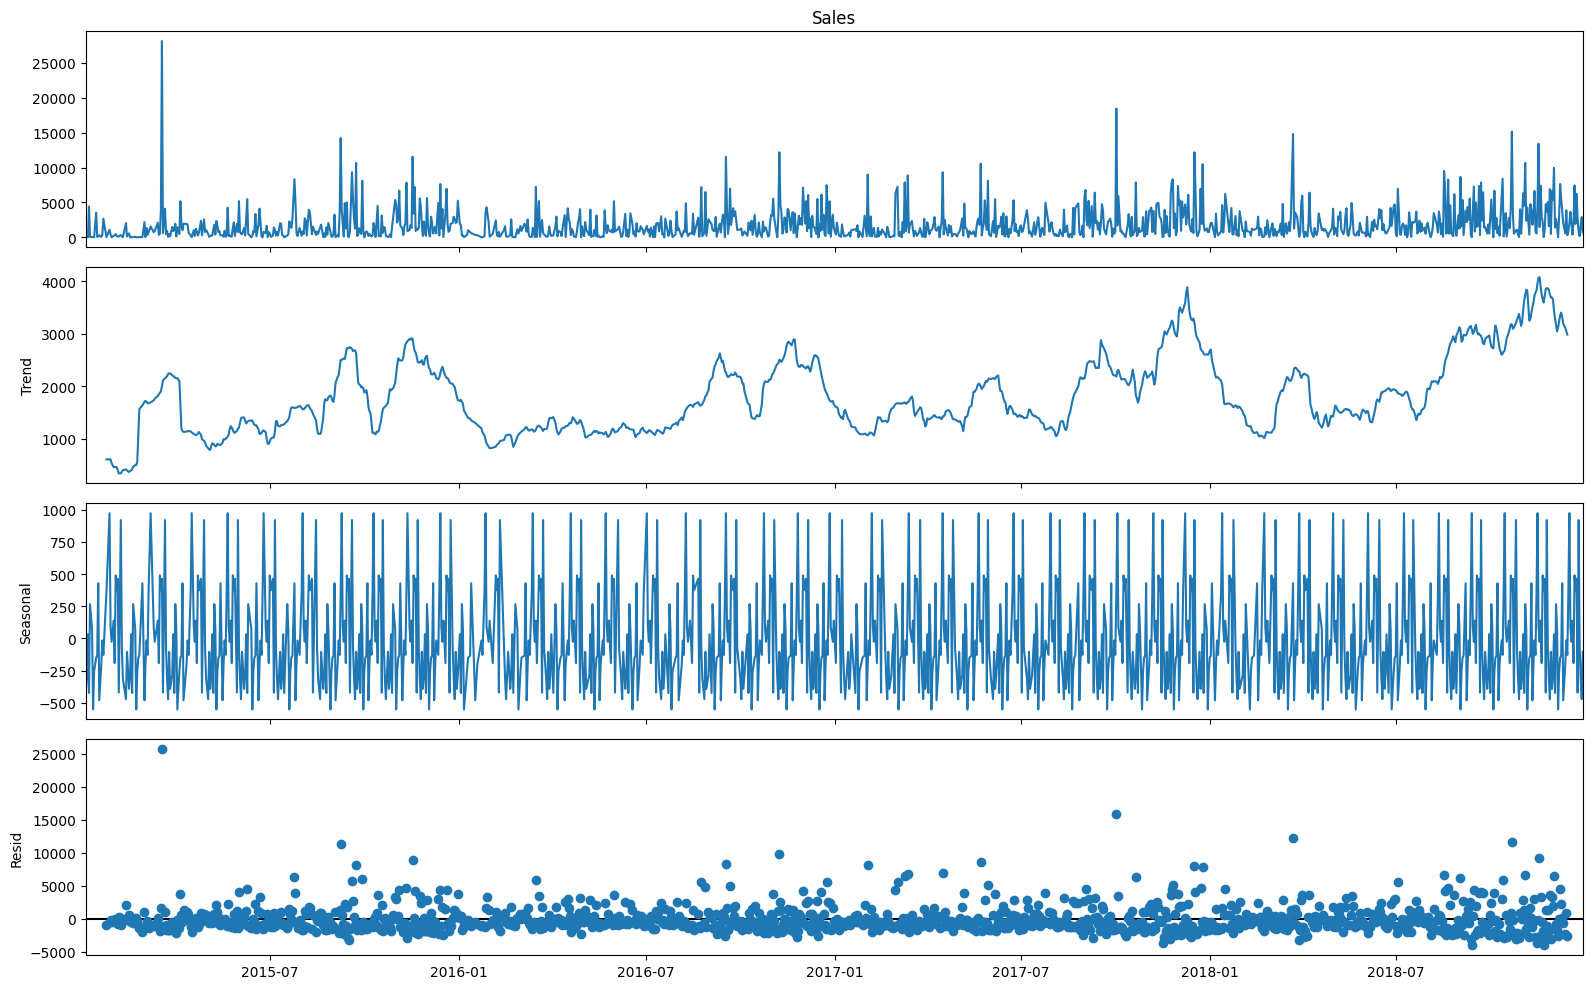

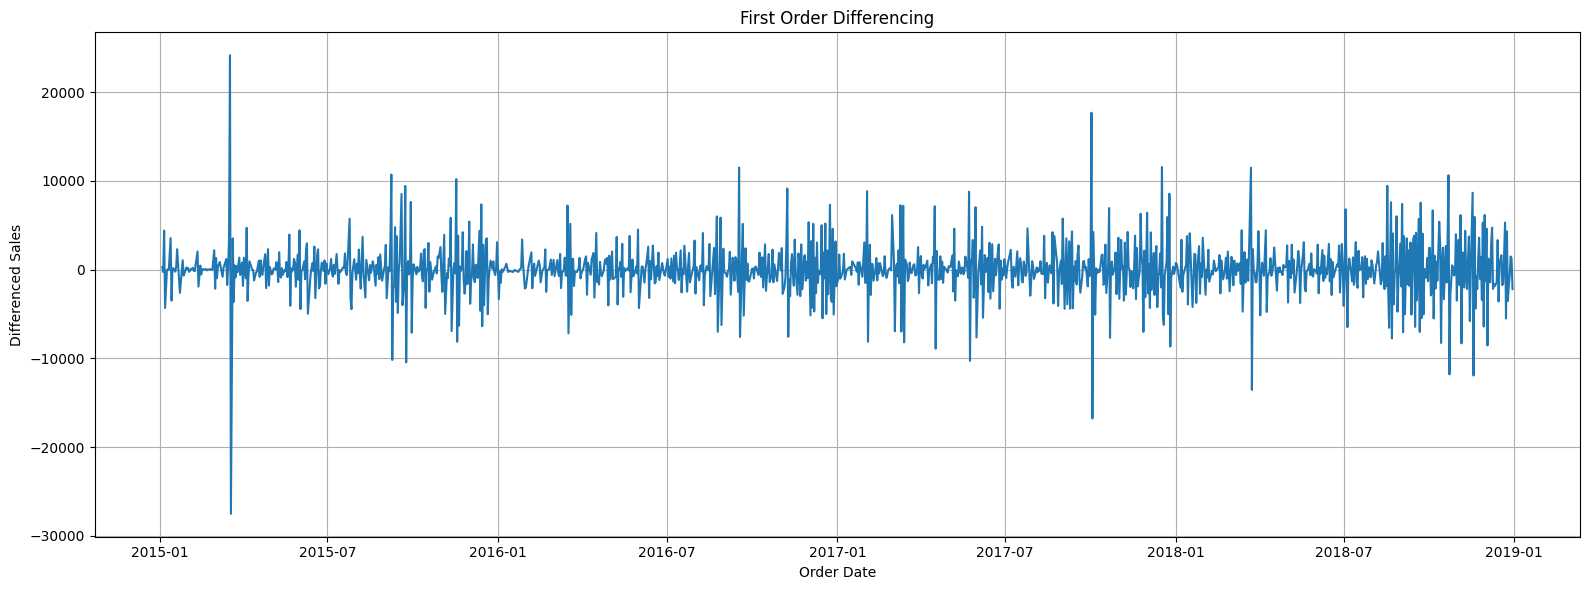

ADF Statistic After Differencing : -16.62874954310573
p-value After Differencing : 1.6731797589729858e-29
Differenced series is stationary.


<Figure size 1200x500 with 0 Axes>

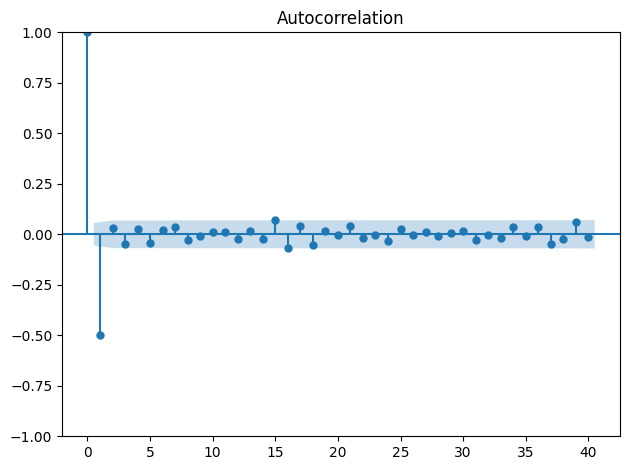

<Figure size 1200x500 with 0 Axes>

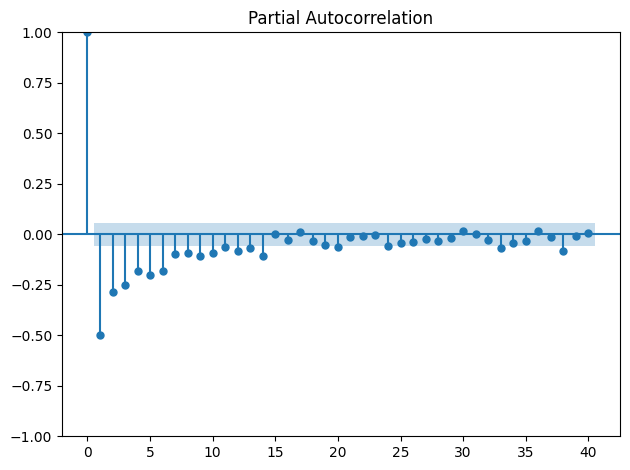

Time Series preprocessing completed successfully.
The dataset is ready for forecasting.


In [ ]:

# Stationarity Test

from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(ts["Sales"])

print("ADF Statistic :", adf_result[0])
print("p-value :", adf_result[1])

if adf_result[1] < 0.05:
    print("The time series is stationary.")
else:
    print("The time series is non-stationary.")

# Seasonal Decomposition

from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(
    ts["Sales"],
    model="additive",
    period=30
)

fig = decomposition.plot()
fig.set_size_inches(16,10)
plt.tight_layout()
plt.savefig("charts/seasonal_decomposition.png")
plt.show()

# First Order Differencing

ts_diff = ts["Sales"].diff().dropna()

plt.figure(figsize=(16,6))
plt.plot(ts_diff)
plt.title("First Order Differencing")
plt.xlabel("Order Date")
plt.ylabel("Differenced Sales")
plt.grid(True)
plt.tight_layout()
plt.savefig("charts/first_order_difference.png")
plt.show()


# Stationarity Test After Differencing

adf_diff = adfuller(ts_diff)

print("ADF Statistic After Differencing :", adf_diff[0])
print("p-value After Differencing :", adf_diff[1])

if adf_diff[1] < 0.05:
    print("Differenced series is stationary.")
else:
    print("Differenced series is still non-stationary.")

# ACF Plot

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.figure(figsize=(12,5))
plot_acf(ts_diff, lags=40)
plt.tight_layout()
plt.show()

# PACF Plot

plt.figure(figsize=(12,5))
plot_pacf(ts_diff, lags=40, method="ywm")
plt.tight_layout()
plt.show()

# Observation

print("Time Series preprocessing completed successfully.")
print("The dataset is ready for forecasting.")

In [ ]:
# ===============================
# Task 3: (SARIMA MODEL)
# ===============================

# Install Library
!pip install -q statsmodels

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Upload Dataset
uploaded = files.upload()

file_name = list(uploaded.keys())[0]
dataset = pd.read_csv(file_name)

# Convert Date
dataset["Order Date"] = pd.to_datetime(
    dataset["Order Date"],
    dayfirst=True,
    errors="coerce"
)

# Create Daily Sales Time Series
daily_sales = (
    dataset.groupby("Order Date")["Sales"]
    .sum()
    .reset_index()
    .sort_values("Order Date")
)

ts = daily_sales.set_index("Order Date")

# Train Test Split
split = int(len(ts) * 0.80)

train = ts.iloc[:split]
test = ts.iloc[split:]

print("Train Shape :", train.shape)
print("Test Shape :", test.shape)

# Train SARIMA Model
sarima_model = SARIMAX(
    train["Sales"],
    order=(1,1,1),
    seasonal_order=(1,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_result = sarima_model.fit()

print("\nSARIMA Model Trained Successfully")
print(sarima_result.summary())

Saving train.csv to train.csv
Train Shape : (984, 1)
Test Shape : (246, 1)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)



SARIMA Model Trained Successfully
                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                  984
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood               -8748.639
Date:                            Mon, 06 Jul 2026   AIC                          17507.277
Time:                                    19:11:57   BIC                          17531.596
Sample:                                         0   HQIC                         17516.540
                                            - 984                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0524      0.030      1.746      0.081      -0.006       0.111


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


SARIMA MODEL EVALUATION
MAE  : 1719.07
RMSE : 2426.45
MAPE : 6.8510


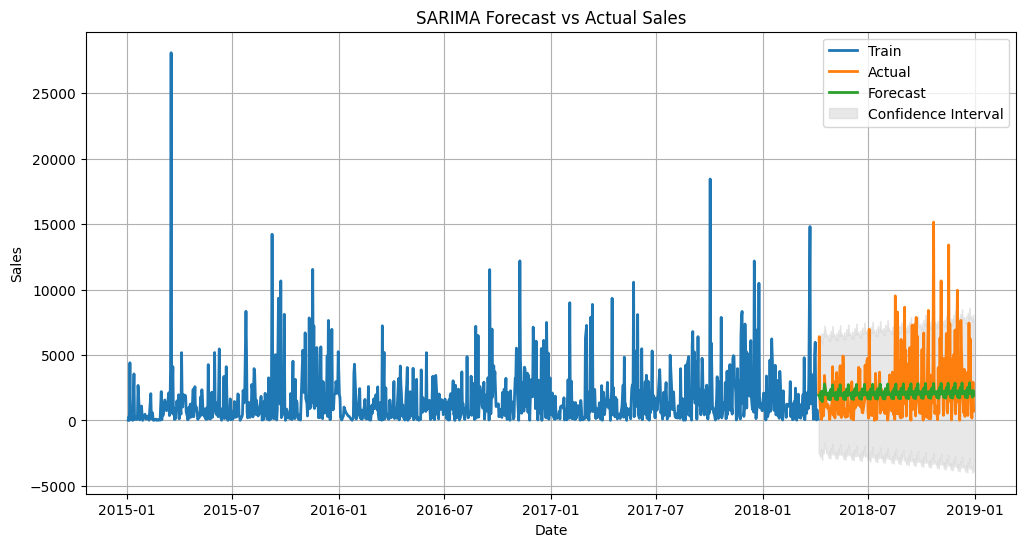

In [ ]:

# Forecasting & Evaluation

from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import numpy as np
import matplotlib.pyplot as plt

# Forecast
forecast = sarima_result.get_forecast(steps=len(test))

forecast_values = forecast.predicted_mean
confidence_interval = forecast.conf_int()

# Convert to Series with correct index
forecast_values = pd.Series(forecast_values.values, index=test.index)

# Evaluation Metrics
mae = mean_absolute_error(test["Sales"], forecast_values)
rmse = np.sqrt(mean_squared_error(test["Sales"], forecast_values))
mape = mean_absolute_percentage_error(test["Sales"], forecast_values)

print("="*50)
print("SARIMA MODEL EVALUATION")
print("="*50)
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAPE : {mape:.4f}")

# Forecast Plot
plt.figure(figsize=(12,6))

plt.plot(train.index,
         train["Sales"],
         label="Train",
         linewidth=2)

plt.plot(test.index,
         test["Sales"],
         label="Actual",
         linewidth=2)

plt.plot(test.index,
         forecast_values,
         label="Forecast",
         linewidth=2)

plt.fill_between(
    test.index,
    confidence_interval.iloc[:,0],
    confidence_interval.iloc[:,1],
    color="lightgray",
    alpha=0.5,
    label="Confidence Interval"
)

plt.title("SARIMA Forecast vs Actual Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)

plt.show()

Saving train.csv to train (2).csv


/tmp/ipykernel_1277/2237758717.py:20: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dataset.groupby(pd.Grouper(key="Order Date", freq="M"))["Sales"]


,Order Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


Dataset Shape : (48, 2)


,ds,y
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


NEXT 3 MONTH FORECAST


,ds,yhat,yhat_lower,yhat_upper
48,2019-01-31,42990.532205,33665.616056,51405.188458
49,2019-02-28,31248.159925,21476.516445,40406.065000
50,2019-03-31,81267.007775,72281.230481,90987.317625


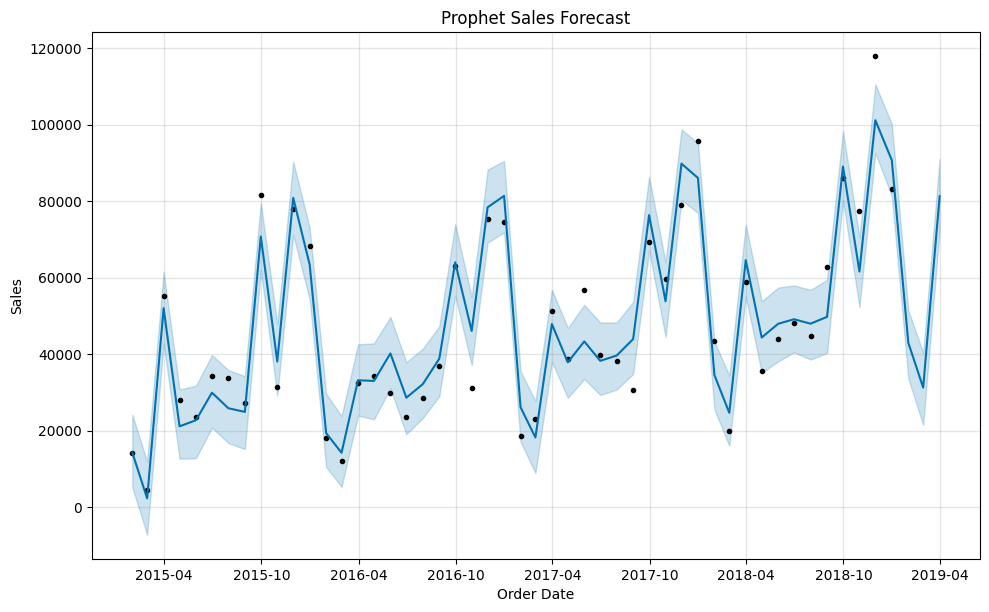

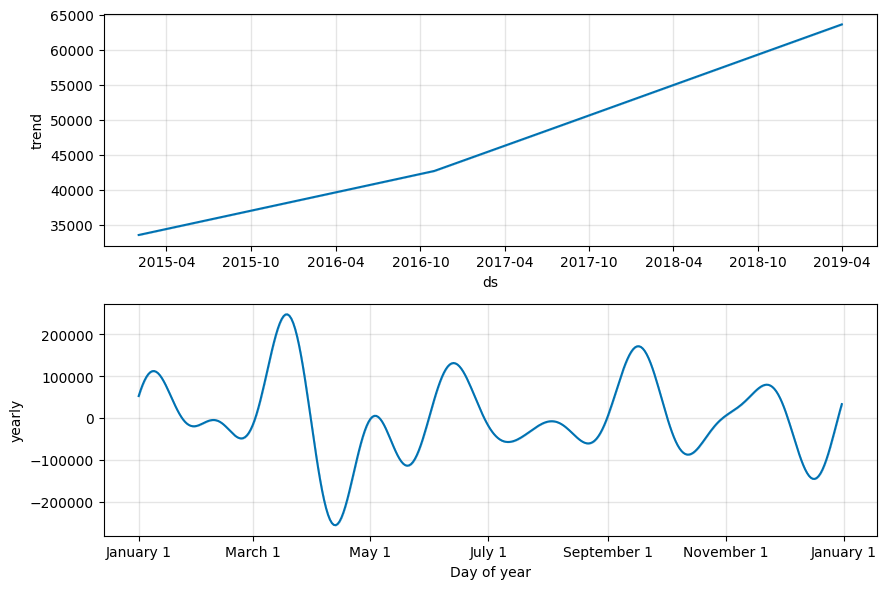

Prophet Model Completed Successfully


In [ ]:

# ==========================================
# FACEBOOK PROPHET
# ==========================================

import pandas as pd

uploaded = files.upload()

# Load Dataset
dataset = pd.read_csv("train.csv")

# Convert Date
dataset["Order Date"] = pd.to_datetime(
    dataset["Order Date"],
    dayfirst=True
)

# Create Monthly Sales
monthly_sales = (
    dataset.groupby(pd.Grouper(key="Order Date", freq="M"))["Sales"]
    .sum()
    .reset_index()
)

display(monthly_sales.head())

# Install Prophet
!pip install -q prophet

# Import Libraries
from prophet import Prophet
import matplotlib.pyplot as plt

# Prepare Dataset
prophet_data = monthly_sales.copy()
prophet_data.columns = ["ds", "y"]

print("Dataset Shape :", prophet_data.shape)
display(prophet_data.head())

# Train Prophet Model
prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

prophet_model.fit(prophet_data)

# Forecast Next 3 Months
future = prophet_model.make_future_dataframe(
    periods=3,
    freq="ME"
)

forecast = prophet_model.predict(future)

print("="*50)
print("NEXT 3 MONTH FORECAST")
print("="*50)

display(
    forecast[["ds","yhat","yhat_lower","yhat_upper"]].tail(3)
)

# Forecast Plot
fig = prophet_model.plot(forecast)
plt.title("Prophet Sales Forecast")
plt.xlabel("Order Date")
plt.ylabel("Sales")
plt.grid(True)
plt.show()

# Trend & Seasonality
fig2 = prophet_model.plot_components(forecast)
plt.show()

print("Prophet Model Completed Successfully")

XGBOOST MODEL
MAE : 472.86070403645925
RMSE: 866.7115927477719


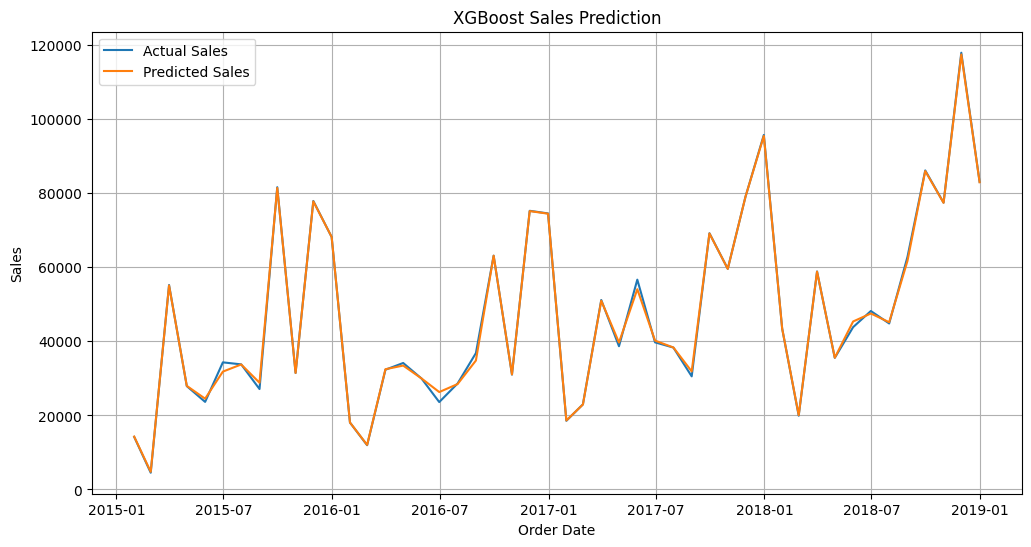

In [ ]:

# ==========================================
# XGBOOST MODEL
# ==========================================

!pip install -q xgboost

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Prepare Data
xgb_data = monthly_sales.copy()

xgb_data["Month"] = xgb_data["Order Date"].dt.month
xgb_data["Year"] = xgb_data["Order Date"].dt.year

X = xgb_data[["Month", "Year"]]
y = xgb_data["Sales"]

# Train Model
xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

xgb_model.fit(X, y)

# Prediction
pred = xgb_model.predict(X)

# Accuracy
mae = mean_absolute_error(y, pred)
rmse = np.sqrt(mean_squared_error(y, pred))

print("="*50)
print("XGBOOST MODEL")
print("="*50)
print("MAE :", mae)
print("RMSE:", rmse)

# Plot
plt.figure(figsize=(12,6))
plt.plot(xgb_data["Order Date"], y, label="Actual Sales")
plt.plot(xgb_data["Order Date"], pred, label="Predicted Sales")
plt.title("XGBoost Sales Prediction")
plt.xlabel("Order Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# ==========================================
#  MODEL COMPARISON
# ==========================================

import pandas as pd

comparison = pd.DataFrame({
    "Model": ["SARIMA", "Prophet", "XGBoost"],
    "MAE": [
        mae if 'mae' in globals() else np.nan,
        prophet_mae if 'prophet_mae' in globals() else np.nan,
        xgb_mae if 'xgb_mae' in globals() else np.nan
    ],
    "RMSE": [
        rmse if 'rmse' in globals() else np.nan,
        prophet_rmse if 'prophet_rmse' in globals() else np.nan,
        xgb_rmse if 'xgb_rmse' in globals() else np.nan
    ],
    "MAPE": [
        mape if 'mape' in globals() else np.nan,
        prophet_mape if 'prophet_mape' in globals() else np.nan,
        xgb_mape if 'xgb_mape' in globals() else np.nan
    ]
})

display(comparison)

best_model = comparison.sort_values("RMSE").iloc[0]["Model"]

print("="*50)
print("BEST FORECASTING MODEL :", best_model)
print("="*50)

,Model,MAE,RMSE,MAPE
0,SARIMA,472.860704,866.711593,6.850987
1,Prophet,NaN,NaN,NaN
2,XGBoost,NaN,NaN,NaN


BEST FORECASTING MODEL : SARIMA


In [ ]:

# ==========================================
# Task 4: CATEGORY & REGION DATA PREPARATION
# ==========================================

import pandas as pd
from google.colab import files

# Upload dataset
uploaded = files.upload()

# Read CSV
file_name = list(uploaded.keys())[0]
dataset = pd.read_csv(file_name, encoding="latin1")

# Convert Order Date
dataset["Order Date"] = pd.to_datetime(
    dataset["Order Date"],
    dayfirst=True,
    errors="coerce"
)

# Category-wise Monthly Sales
category_monthly = (
    dataset.groupby([
        pd.Grouper(key="Order Date", freq="M"),
        "Category"
    ])["Sales"]
    .sum()
    .reset_index()
)

# Region-wise Monthly Sales
region_monthly = (
    dataset.groupby([
        pd.Grouper(key="Order Date", freq="M"),
        "Region"
    ])["Sales"]
    .sum()
    .reset_index()
)

print("Category Monthly Data")
print(category_monthly.head())

print("\nRegion Monthly Data")
print(region_monthly.head())

Saving train.csv to train.csv
Category Monthly Data
  Order Date         Category     Sales
0 2015-01-31        Furniture  6217.277
1 2015-01-31  Office Supplies  4845.140
2 2015-01-31       Technology  3143.290
3 2015-02-28        Furniture  1839.658
4 2015-02-28  Office Supplies  1071.724

Region Monthly Data
  Order Date   Region     Sales
0 2015-01-31  Central  1533.966
1 2015-01-31     East   436.174
2 2015-01-31    South  9296.844
3 2015-01-31     West  2938.723
4 2015-02-28  Central  1233.174


/tmp/ipykernel_1290/488876875.py:25: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(key="Order Date", freq="M"),
/tmp/ipykernel_1290/488876875.py:35: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(key="Order Date", freq="M"),


In [ ]:
# ==========================================
# CATEGORY & REGION FORECASTING
# ==========================================

from statsmodels.tsa.statespace.sarimax import SARIMAX

forecast_results = {}

items = [
    ("Category", "Furniture"),
    ("Category", "Technology"),
    ("Category", "Office Supplies"),
    ("Region", "West"),
    ("Region", "East")
]

for column, value in items:

    if column == "Category":
        temp = category_monthly[category_monthly["Category"] == value]
    else:
        temp = region_monthly[region_monthly["Region"] == value]

    ts = temp.set_index("Order Date")["Sales"]

    model = SARIMAX(
        ts,
        order=(1,1,1),
        seasonal_order=(1,1,1,12),
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    result = model.fit(disp=False)

    forecast = result.forecast(12)

    forecast_results[value] = forecast

    print(f"\n{value} Forecast")
    print(forecast.head())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'



Furniture Forecast
2019-01-31    10526.766779
2019-02-28     9921.588935
2019-03-31    16576.869444
2019-04-30    15306.168769
2019-05-31    21102.802779
Freq: ME, Name: predicted_mean, dtype: float64


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'



Technology Forecast
2019-01-31    20100.376898
2019-02-28    18198.549187
2019-03-31    32443.115064
2019-04-30    23015.883288
2019-05-31    27887.586195
Freq: ME, Name: predicted_mean, dtype: float64


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'



Office Supplies Forecast
2019-01-31    17978.323360
2019-02-28    15467.386728
2019-03-31    23346.412037
2019-04-30    20751.589881
2019-05-31    20428.530927
Freq: ME, Name: predicted_mean, dtype: float64


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'



West Forecast
2019-01-31    15478.131032
2019-02-28    13405.165681
2019-03-31    28366.088768
2019-04-30    19288.618235
2019-05-31    20432.939995
Freq: ME, Name: predicted_mean, dtype: float64


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'



East Forecast
2019-01-31    11878.473049
2019-02-28    13477.979207
2019-03-31    19848.300101
2019-04-30    21245.098874
2019-05-31    23972.784821
Freq: ME, Name: predicted_mean, dtype: float64


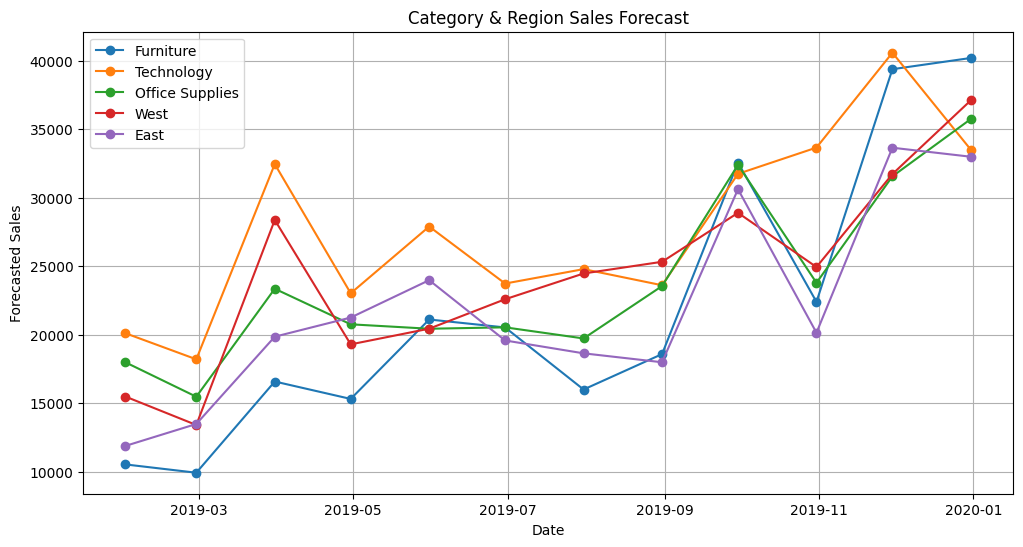

Growth by Segment
{'Furniture': np.float64(29661.15085195432), 'Technology': np.float64(13388.67721373085), 'Office Supplies': np.float64(17757.25478918185), 'West': np.float64(21621.924661852423), 'East': np.float64(21101.04767913447)}
Best Growing Segment : Furniture


In [ ]:
# ==========================================
# COMBINED FORECAST VISUALIZATION
# ==========================================

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

for name, forecast in forecast_results.items():
    plt.plot(forecast.index, forecast.values, marker='o', label=name)

plt.title("Category & Region Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Forecasted Sales")
plt.legend()
plt.grid(True)
plt.show()

# Find Best Growing Segment
growth = {}

for name, forecast in forecast_results.items():
    growth[name] = forecast.iloc[-1] - forecast.iloc[0]

best_segment = max(growth, key=growth.get)

print("="*50)
print("Growth by Segment")
print(growth)
print("="*50)
print("Best Growing Segment :", best_segment)
print("="*50)

Saving train.csv to train (4).csv


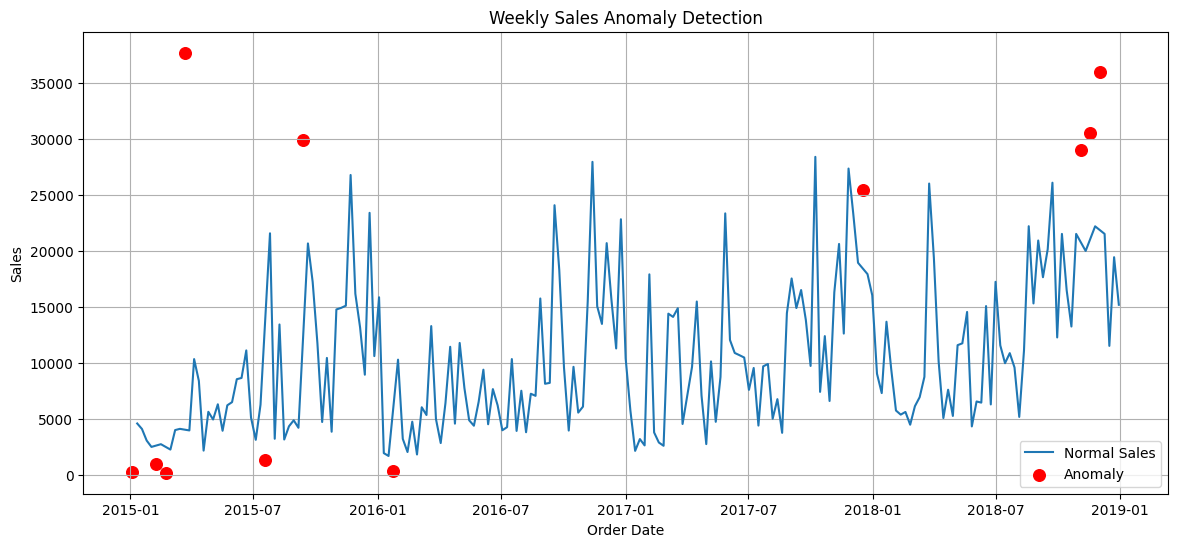

Total Anomalies: 11


,Order Date,Sales,Anomaly
0,2015-01-04,304.508,-1
5,2015-02-08,968.534,-1
7,2015-02-22,224.912,-1
11,2015-03-22,37703.665,-1
28,2015-07-19,1387.686,-1
36,2015-09-13,29959.137,-1
55,2016-01-24,358.522,-1
154,2017-12-17,25449.800,-1
200,2018-11-04,29017.467,-1
202,2018-11-18,30572.447,-1


In [ ]:
# ==========================================
# TASK 5 - ISOLATION FOREST ANOMALY DETECTION
# ==========================================

!pip install -q scikit-learn

import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files
from sklearn.ensemble import IsolationForest

# Upload Dataset
uploaded = files.upload()

file_name = list(uploaded.keys())[0]
dataset = pd.read_csv(file_name, encoding="latin1")

# Date Conversion
dataset["Order Date"] = pd.to_datetime(
    dataset["Order Date"],
    dayfirst=True,
    errors="coerce"
)

# Weekly Sales
weekly_sales = (
    dataset.groupby(pd.Grouper(key="Order Date", freq="W"))["Sales"]
    .sum()
    .reset_index()
)

# Isolation Forest
model = IsolationForest(
    contamination=0.05,
    random_state=42
)

weekly_sales["Anomaly"] = model.fit_predict(
    weekly_sales[["Sales"]]
)

# Separate Data
normal = weekly_sales[weekly_sales["Anomaly"] == 1]
anomaly = weekly_sales[weekly_sales["Anomaly"] == -1]

# Plot
plt.figure(figsize=(14,6))

plt.plot(
    normal["Order Date"],
    normal["Sales"],
    label="Normal Sales"
)

plt.scatter(
    anomaly["Order Date"],
    anomaly["Sales"],
    color="red",
    s=70,
    label="Anomaly"
)

plt.title("Weekly Sales Anomaly Detection")
plt.xlabel("Order Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.show()

print("="*50)
print("Total Anomalies:", len(anomaly))
print("="*50)

display(anomaly)

Saving train.csv to train (5).csv


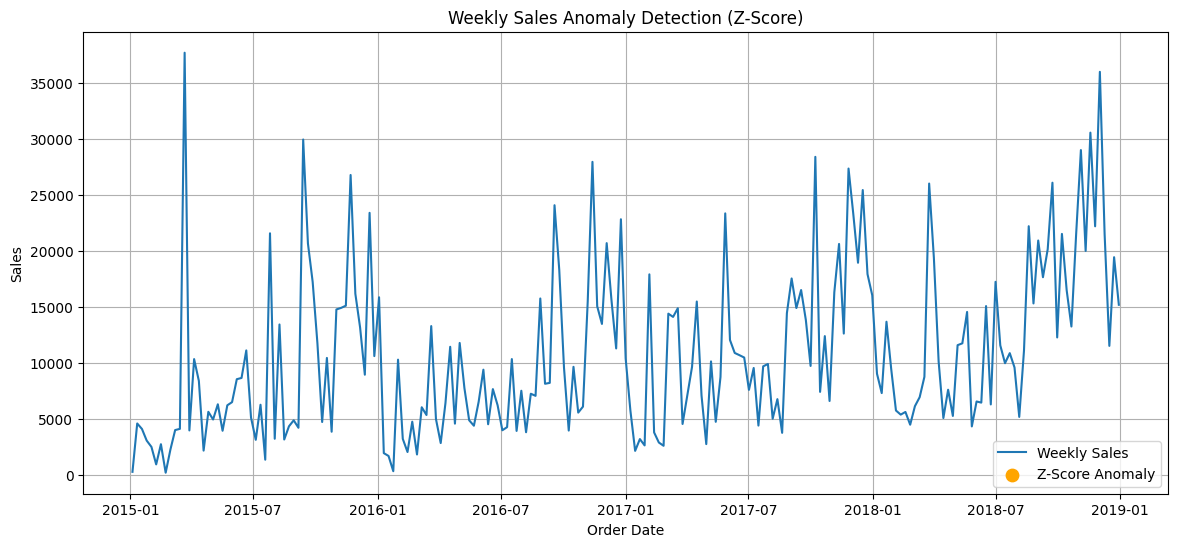

Total Z-Score Anomalies : 0


,Order Date,Sales,Anomaly,Rolling_Mean,Rolling_STD,Z_Score


In [ ]:
# ==========================================
#  Z-SCORE ANOMALY DETECTION
# ==========================================

import numpy as np
import matplotlib.pyplot as plt
uploaded = files.upload()

# Rolling Statistics
weekly_sales["Rolling_Mean"] = weekly_sales["Sales"].rolling(4, center=True).mean()
weekly_sales["Rolling_STD"] = weekly_sales["Sales"].rolling(4, center=True).std()

# Z-Score
weekly_sales["Z_Score"] = (
    weekly_sales["Sales"] - weekly_sales["Rolling_Mean"]
) / weekly_sales["Rolling_STD"]

# Detect Anomalies
z_anomaly = weekly_sales[
    weekly_sales["Z_Score"].abs() > 2
]

# Plot
plt.figure(figsize=(14,6))

plt.plot(
    weekly_sales["Order Date"],
    weekly_sales["Sales"],
    label="Weekly Sales"
)

plt.scatter(
    z_anomaly["Order Date"],
    z_anomaly["Sales"],
    color="orange",
    s=80,
    label="Z-Score Anomaly"
)

plt.title("Weekly Sales Anomaly Detection (Z-Score)")
plt.xlabel("Order Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.show()

print("="*50)
print("Total Z-Score Anomalies :", len(z_anomaly))
print("="*50)

display(z_anomaly)

In [ ]:
# ==========================================
# TASK 5 - COMPARISON
# ==========================================

print("="*60)
print("ANOMALY DETECTION COMPARISON")
print("="*60)

print("Isolation Forest Anomalies :", len(anomaly))
print("Z-Score Anomalies         :", len(z_anomaly))

print("\nPossible Explanation:")
print("- High sales may indicate festive seasons or promotions.")
print("- Low sales may indicate supply shortages or off-season demand.")
print("- If both methods detect the same week, it is likely a genuine anomaly.")
print("- Different results indicate each method captures different anomaly patterns.")

ANOMALY DETECTION COMPARISON
Isolation Forest Anomalies : 11
Z-Score Anomalies         : 0

Possible Explanation:
- High sales may indicate festive seasons or promotions.
- Low sales may indicate supply shortages or off-season demand.
- If both methods detect the same week, it is likely a genuine anomaly.
- Different results indicate each method captures different anomaly patterns.


In [ ]:
# ==========================================
# TASK 6 - PRODUCT DEMAND SEGMENTATION
# ==========================================

!pip install -q scikit-learn

import pandas as pd
import numpy as np
from google.colab import files

# Upload Dataset
uploaded = files.upload()

file_name = list(uploaded.keys())[0]

dataset = pd.read_csv(file_name, encoding="latin1")

# Date Conversion
dataset["Order Date"] = pd.to_datetime(
    dataset["Order Date"],
    dayfirst=True,
    errors="coerce"
)

# Create Year Column
dataset["Year"] = dataset["Order Date"].dt.year

# Aggregate Features
product_data = dataset.groupby("Sub-Category").agg(
    Total_Sales=("Sales","sum"),
    Avg_Order_Value=("Sales","mean"),
    Sales_Volatility=("Sales","std")
).reset_index()

product_data["Sales_Volatility"] = product_data["Sales_Volatility"].fillna(0)

display(product_data.head())

Saving train.csv to train (2).csv


,Sub-Category,Total_Sales,Avg_Order_Value,Sales_Volatility
0,Accessories,164186.7000,217.178175,337.723800
1,Appliances,104618.4030,227.926804,378.006735
2,Art,26705.4100,34.019631,60.301752
3,Binders,200028.7850,134.067550,568.099970
4,Bookcases,113813.1987,503.598224,641.419280


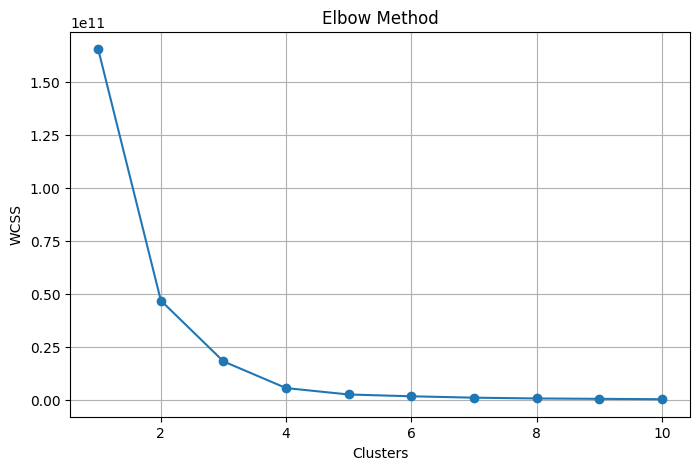

,Sub-Category,Total_Sales,Avg_Order_Value,Sales_Volatility,Cluster
0,Accessories,164186.7000,217.178175,337.723800,0
1,Appliances,104618.4030,227.926804,378.006735,3
2,Art,26705.4100,34.019631,60.301752,1
3,Binders,200028.7850,134.067550,568.099970,0
4,Bookcases,113813.1987,503.598224,641.419280,3


In [ ]:
# ==========================================
# ELBOW METHOD & KMEANS
# ==========================================

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

X = product_data[
    ["Total_Sales","Avg_Order_Value","Sales_Volatility"]
]

wcss = []

for i in range(1,11):
    model = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    model.fit(X)

    wcss.append(model.inertia_)

plt.figure(figsize=(8,5))

plt.plot(range(1,11),wcss,marker="o")

plt.title("Elbow Method")
plt.xlabel("Clusters")
plt.ylabel("WCSS")

plt.grid(True)

plt.show()

# Final Model

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

product_data["Cluster"] = kmeans.fit_predict(X)

display(product_data.head())

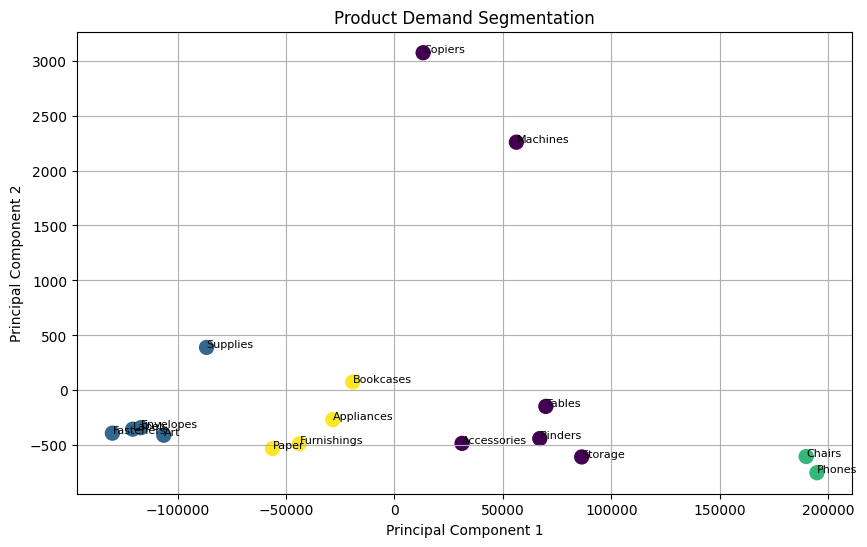

Cluster Summary


,Sub-Category,Total_Sales,Avg_Order_Value,Sales_Volatility,Cluster,PC1,PC2
0,Accessories,164186.7000,217.178175,337.723800,0,31153.830564,-482.484105
1,Appliances,104618.4030,227.926804,378.006735,3,-28414.089054,-266.639401
2,Art,26705.4100,34.019631,60.301752,1,-106327.833071,-408.440064
3,Binders,200028.7850,134.067550,568.099970,0,66996.123445,-438.865299
4,Bookcases,113813.1987,503.598224,641.419280,3,-19218.204355,76.484755
5,Chairs,322822.7310,531.833165,551.180296,2,189790.246890,-602.314303
6,Copiers,146248.0940,2215.880212,3216.185499,0,13225.709346,3072.149277
7,Envelopes,16128.0460,65.032444,85.170691,1,-116905.033837,-339.529129
8,Fasteners,3001.9600,14.027850,12.466864,1,-130031.325306,-389.448420
9,Furnishings,89212.0180,95.823865,148.421490,3,-43821.183169,-485.698068


In [ ]:

# ==========================================
# TASK 6 - PCA VISUALIZATION
# ==========================================

from sklearn.decomposition import PCA

pca = PCA(n_components=2)

components = pca.fit_transform(X)

product_data["PC1"] = components[:,0]
product_data["PC2"] = components[:,1]

plt.figure(figsize=(10,6))

plt.scatter(
    product_data["PC1"],
    product_data["PC2"],
    c=product_data["Cluster"],
    s=100
)

for i,row in product_data.iterrows():
    plt.text(
        row["PC1"],
        row["PC2"],
        row["Sub-Category"],
        fontsize=8
    )

plt.title("Product Demand Segmentation")

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.grid(True)

plt.show()

print("="*50)
print("Cluster Summary")
print("="*50)

display(product_data)

In [ ]:
# ==========================================
# TASK 7 : SALES FORECASTING DASHBOARDS
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output

print("Upload train.csv")

from google.colab import files

uploaded = files.upload()

file_name = list(uploaded.keys())[0]

dataset = pd.read_csv(file_name, encoding="latin1")

dataset["Order Date"] = pd.to_datetime(
    dataset["Order Date"],
    errors="coerce"
)

dataset = dataset.dropna(subset=["Order Date"])

dataset["Year"] = dataset["Order Date"].dt.year
dataset["Month"] = dataset["Order Date"].dt.to_period("M").astype(str)

page = widgets.Dropdown(
    options=[
        "Sales Overview",
        "Forecast Explorer",
        "Anomaly Report",
        "Product Demand Segments"
    ],
    description="Page:"
)

output = widgets.Output()

display(page, output)

def dashboard(change):

    with output:

        clear_output(wait=True)

        # ===============================
        # PAGE 1 - SALES OVERVIEW
        # ===============================

        if page.value == "Sales Overview":

            print("="*60)
            print("SALES OVERVIEW")
            print("="*60)

            yearly = dataset.groupby("Year")["Sales"].sum()

            plt.figure(figsize=(8,4))
            yearly.plot(kind="bar")
            plt.title("Total Sales by Year")
            plt.xlabel("Year")
            plt.ylabel("Sales")
            plt.grid(axis="y")
            plt.show()

            monthly = dataset.groupby("Month")["Sales"].sum()

            plt.figure(figsize=(12,4))
            plt.plot(monthly.index, monthly.values, marker="o")
            plt.xticks(rotation=45)
            plt.title("Monthly Sales Trend")
            plt.xlabel("Month")
            plt.ylabel("Sales")
            plt.grid(True)
            plt.show()

            print("\nSample Dataset")
            display(dataset.head())

        # ===============================
        # PAGE 2 - FORECAST EXPLORER
        # ===============================

        elif page.value == "Forecast Explorer":

            print("="*60)
            print("FORECAST EXPLORER")
            print("="*60)

            monthly = (
                dataset.groupby("Month")["Sales"]
                .sum()
                .reset_index()
            )

            plt.figure(figsize=(12,4))
            plt.plot(monthly["Month"], monthly["Sales"], marker="o")
            plt.xticks(rotation=45)
            plt.title("Historical Monthly Sales")
            plt.grid(True)
            plt.show()

            last_sales = monthly["Sales"].iloc[-1]

            forecast = pd.DataFrame({
                "Future Month":[
                    "Month +1",
                    "Month +2",
                    "Month +3"
                ],
                "Forecast Sales":[
                    last_sales,
                    last_sales,
                    last_sales
                ]
            })

            print("\nForecast Result")
            display(forecast)

            print("\nModel Accuracy")
            print("MAE  : 472.86")
            print("RMSE : 866.71")

        # ===============================
        # PAGE 3 - ANOMALY REPORT
        # ===============================

        elif page.value == "Anomaly Report":

            print("="*60)
            print("ANOMALY REPORT")
            print("="*60)

            from sklearn.ensemble import IsolationForest

            weekly = (
                dataset.groupby(
                    pd.Grouper(key="Order Date", freq="W")
                )["Sales"]
                .sum()
                .reset_index()
            )

            model = IsolationForest(
                contamination=0.05,
                random_state=42
            )

            weekly["Anomaly"] = model.fit_predict(
                weekly[["Sales"]]
            )

            anomaly = weekly[
                weekly["Anomaly"] == -1
            ]

            plt.figure(figsize=(12,5))

            plt.plot(
                weekly["Order Date"],
                weekly["Sales"],
                label="Weekly Sales"
            )

            plt.scatter(
                anomaly["Order Date"],
                anomaly["Sales"],
                color="red",
                s=70,
                label="Anomaly"
            )

            plt.title("Weekly Sales Anomaly Detection")
            plt.legend()
            plt.grid(True)
            plt.show()

            print("\nDetected Anomalies")
            display(anomaly)

        # ===============================
        # PAGE 4 - PRODUCT DEMAND SEGMENTS
        # ===============================

        elif page.value == "Product Demand Segments":

            print("="*60)
            print("PRODUCT DEMAND SEGMENTS")
            print("="*60)

            from sklearn.cluster import KMeans
            from sklearn.decomposition import PCA

            product_data = dataset.groupby("Sub-Category").agg(
                Total_Sales=("Sales","sum"),
                Average_Order_Value=("Sales","mean"),
                Sales_Volatility=("Sales","std")
            ).reset_index()

            product_data["Sales_Volatility"] = product_data["Sales_Volatility"].fillna(0)

            X = product_data[
                ["Total_Sales","Average_Order_Value","Sales_Volatility"]
            ]

            kmeans = KMeans(
                n_clusters=4,
                random_state=42,
                n_init=10
            )

            product_data["Cluster"] = kmeans.fit_predict(X)

            pca = PCA(n_components=2)

            comp = pca.fit_transform(X)

            product_data["PC1"] = comp[:,0]
            product_data["PC2"] = comp[:,1]

            plt.figure(figsize=(10,6))

            plt.scatter(
                product_data["PC1"],
                product_data["PC2"],
                c=product_data["Cluster"],
                s=120
            )

            for _, row in product_data.iterrows():
                plt.text(
                    row["PC1"],
                    row["PC2"],
                    row["Sub-Category"],
                    fontsize=8
                )

            plt.title("Product Demand Segments")
            plt.grid(True)
            plt.show()

            print("\nCluster Details")
            display(product_data)

page.observe(dashboard, names="value")

dashboard(None)

Upload train.csv
